In [1]:
import matplotlib.pyplot as plt
import numpy as np

Governing equations are
\begin{align}
\partial_t \eta + \partial_x \left( h u \right) + \partial_y \left( h u \right) & = 0 \\
\partial_t u - q h u + \partial_x \left( g \eta + K \right) & = \frac{\tau^x - \epsilon u}{D} + \nu \nabla^2 u \\
\partial_t v + q h v + \partial_y \left( g \eta + K \right) & = \frac{\tau^y - \epsilon v}{D} + \nu \nabla^2 v
\end{align}
where
\begin{align}
h & = D + \eta \\
K & = \frac{1}{2} \left( u^2 + v^2 \right) \\
q & = \frac{ f + \zeta }{ h } \\
\zeta & = \partial_x v - \partial_y u \\
f & = f_o + \beta y
\end{align}

$u$, $v$ and $h$ will be staggered on an Arakawa C-grid using south-west indexing convention, i.e. $u_{i-1/2,j}=u[j,i]$ and $v_{i,j-1/2}=v[j,i]$ are west and south of $h_{i,j}=h[j,i]$ respectively.

Time discretization and algorithm (only partial spatial discretization so far):
\begin{align}
H^u & = \tilde{ h }^i u^n \\
h^* &= h^n - \frac{\Delta t}{\Delta x} \delta_i H^u \\
H^v & = \tilde{ h^* }^j v^n \\
h^{n+1} &= h^* - \frac{\Delta t}{\Delta y} \delta_i H^v \\
K_{i,j}^n & = \max(0,u_{i-1/2,j}^n)^2 + \min(0,u_{i+1/2,j}^n)^2 + \max(0,v_{i,j-1/2}^n)^2 + \min(0,v_{i,j+1/2}^n)^2 \\
q & = \frac{ f + \delta_i ( v^n \Delta y ) - \delta_j ( u^n \Delta x ) }{ h^{n} \Delta x \Delta y }
\end{align}
and a simultaneous solve of
\begin{align}
\frac{ u^{n+1} - u^n }{ \Delta t}
& = f \left( \alpha_f v^{n+1} + ( 1 - \alpha_f ) v^n \right) +
\left( \tilde{q}^{j} \overline{ H^v }^{ij} - f v^n \right) - \frac{1}{\Delta x} \delta_i \left( g \eta^{n+1} + K^n \right)
+ \frac{\tau^x}{D} - \frac{\epsilon \left( \alpha_\epsilon u^{n+1} + ( 1 - \alpha_\epsilon ) u^n \right)}{D} + \nu \nabla^2 u^n \\
\frac{ v^{n+1} - v^n }{ \Delta t}
& = - f \left( \alpha_f u^{n+1} + ( 1 - \alpha_f ) u^n \right) +
\left( - \tilde{q}^{i} \overline{ H^u }^{ij} + f u^n \right) - \frac{1}{\Delta y} \delta_j \left( g \eta^{n+1} + K^n \right)
+ \frac{\tau^y}{D} - \frac{\epsilon \left( \alpha_\epsilon v^{n+1} + ( 1 - \alpha_\epsilon ) v^n \right)}{D} + \nu \nabla^2 v^n
\end{align}
Note that the linear Coriolis term, $f v$ is included in the non-linear term, $q H^v$, so we have a compensation term added that let's us treat some part of the Coriolis term implicitly in time.
The parameter $\alpha_f$ allows the Coriolis term to be centered in time ($\alpha=1/2$), preserving oscillation amplitudes, or made Euler-backward ($\alpha=1$) in time which damps oscillations without changing the balanced state.
Similarly, $\alpha_\epsilon$ allows the dissipation to be either explicit ($\alpha_\epsilon=0$) or Euler-backward ($\alpha_\epsilon=1$).

Solution of the latter is managed by re-writing in terms of the velocity increment
\begin{align}
\Delta u &= u^{n+1} - u^n \\
\Delta v &= v^{n+1} - v^n
\end{align}
so the coupled problem becomes
\begin{align}
\left( \frac{1}{\Delta t} + \frac{ \alpha_\epsilon \epsilon }{D} \right) \Delta u - f \alpha_f \Delta v
&= \dot{u} \\
\left( \frac{1}{\Delta t} + \frac{ \alpha_\epsilon \epsilon }{D} \right) \Delta v + f \alpha_f \Delta u
&= \dot{v}
\end{align}
where the $\dot{u}$ and $\dot{v}$ are all accelerations evaluated explicitly:
\begin{align}
\dot{u}
& = \tilde{q}^{j} \overline{ H^v }^{ij} - \frac{1}{\Delta x} \delta_i \left( g \eta^{n+1} + K^n \right)
+ \frac{\tau^x}{D} - \frac{\epsilon u^{n}}{D} + \nu \nabla^2 u^n \\
\dot{v}
& = - \tilde{q}^{i} \overline{ H^u }^{ij} - \frac{1}{\Delta y} \delta_j \left( g \eta^{n+1} + K^n \right)
+ \frac{\tau^y}{D} - \frac{\epsilon v^{n}}{D} + \nu \nabla^2 v^n \\
\end{align}

Rearranging for $\Delta u$ and $\Delta v$, we get
\begin{align}
\left( \left( 1 + \frac{ \Delta t \alpha_\epsilon \epsilon }{D} \right)^2 + \alpha_f^2 \Delta t^2  f^2 \right) \Delta u
&= \Delta t^2 f \alpha_f \dot{v} + \Delta t \left( 1 + \frac{ \Delta t \alpha_\epsilon\epsilon }{D} \right)\dot{u} \\
\left( \left( 1 + \frac{ \Delta t \alpha_\epsilon \epsilon }{D} \right)^2 + \alpha_f^2 \Delta t^2  f^2 \right) \Delta v
&= - \Delta t^2  f \alpha_f \dot{u} + \Delta t \left( 1 + \frac{ \Delta t \alpha_\epsilon\epsilon }{D} \right)\dot{v} \\
\end{align}

Finally we apply the spatial discretization (interpolation) needed for the Coriolis terms:
\begin{align}
\left( \left( 1 + \frac{ \Delta t \alpha_\epsilon \epsilon }{D} \right)^2 + \alpha_f^2 \Delta t^2  f^2 \right) \Delta u
&= \Delta t \left( \left( 1 + \frac{ \Delta t \alpha_\epsilon \epsilon }{D} \right)\dot{u} + \Delta t f \alpha_f \overline{ \dot{v} }^{ij} \right) \\
\left( \left( 1 + \frac{ \Delta t \alpha_\epsilon \epsilon }{D} \right)^2 + \alpha_f^2 \Delta t^2  f^2 \right) \Delta v
&= \Delta t \left( \left( 1 + \frac{ \Delta t \alpha_\epsilon \epsilon }{D} \right)\dot{v} - \Delta t f \alpha_f \overline{ \dot{u} }^{ij} \right)
\end{align}

In [2]:
from dqswm import DQSWE

In [3]:
# Check every function returns without error
M = DQSWE(32,
          10., # Gravity [m s-2]
          1000., # Max depth [m]
          1000.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          2.e-11, # df/dy [m-1 s-1]
          1.e-3, # Drag rate [m-1 s-1]
          1.e-1, # Viscosity [m s-2]
          h_relax=0.1 # Forcing rate for eta [s-1]
          )
M.resting_state()
M.flat_topog()
M.bowl_topog()
M.zero_forcing()
M.gyre_forcing()
M.channel_forcing()
M.set_eta_forcing(0.1)
M.perturb_eta(0.01, 10., 500.e3)
M.step(50.)
# _,_,_,_ = M.run(10., 10, 2)
u,v,h,t = M.run( 10., 1, 10)

Grid: dx = 31250.0 [m]
cg = 100.0 [m s-1]
Ld = 1000000.0 [m]
Scales: Ls=epsilon/D/beta = 50000.0 [m]
Scales: Lx/Ld = 1.0
Res: Ld/dx = 32.0
Res: Ls/dx = 1.6
CFL: dt*epsilon/D = 1e-05
CFL: dt*f = 0.00119375
CFL: dt*cg/dx = 0.032
CFL: dt*nu/dx^2 = 1.024e-09
CFL: dt*h_relax = 1.0
nsteps = 10
Time: Trun * fo = 0.01
Time: Trun * ( cg / L ) = 0.01
Running...
...done


Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = 0.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Res: Ld/dx = 0.0
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.05
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 1000
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.5
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 100
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 2.0
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 25
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done


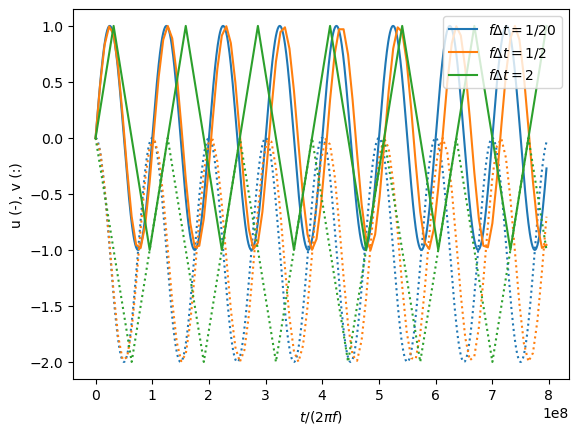

In [4]:
# Check pure intertial oscillations are stable and convergent
M = DQSWE(1,
          0., # Gravity [m s-2]
          1000., # Max depth [m]
          1000.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          0.e-3, # Drag rate [m-1 s-1]
          0 # Viscosity [m s-2]
          )
M.gyre_forcing()
u1, v1, _, time1 = M.run(500., 1, 1000)
M.resting_state()
u2, v2, _, time2 = M.run(5000., 1, 100)
M.resting_state()
u3, v3, _, time3 = M.run(20000., 1, 25)
plt.plot( time1 / ( 2 * np.pi * M.fo ), u1[:,0,0], label=r'$f \Delta t=1/20$' );
plt.plot( time1 / ( 2 * np.pi * M.fo ), v1[:,0,0], ':C0' );
plt.plot( time2 / ( 2 * np.pi * M.fo ), u2[:,0,0], label=r'$f \Delta t=1/2$' );
plt.plot( time2 / ( 2 * np.pi * M.fo ), v2[:,0,0], ':C1' );
plt.plot( time3 / ( 2 * np.pi * M.fo ), u3[:,0,0], label=r'$f \Delta t=2$' );
plt.plot( time3 / ( 2 * np.pi * M.fo ), v3[:,0,0], ':C2' );
plt.xlabel(r"$t / ( 2 \pi f )$");
plt.ylabel("u (-), v (:)")
plt.legend();

Grid: dx = 1000000.0 [m]
cg = 0.0 [m s-1]
Ld = 0.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Res: Ld/dx = 0.0
CFL: dt*epsilon/D = 0.05
CFL: dt*f = 0.05
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 1000
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
CFL: dt*epsilon/D = 0.5
CFL: dt*f = 0.5
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 100
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done
CFL: dt*epsilon/D = 2.0
CFL: dt*f = 2.0
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 25
Time: Trun * fo = 50.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done


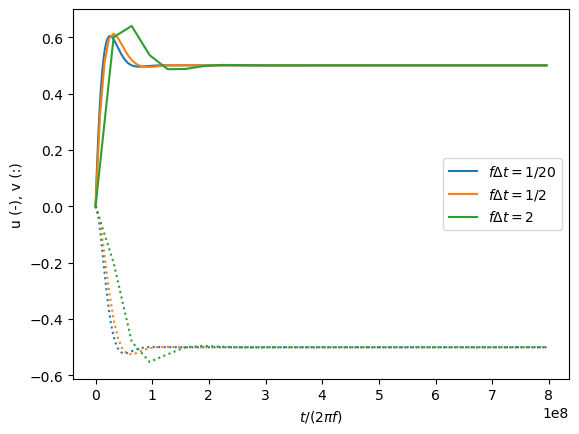

In [5]:
# Check pure damped intertial oscillations are stable and convergent
M = DQSWE(1,
          0., # Gravity [m s-2]
          1000., # Max depth [m]
          1000.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          1.e-1, # Drag rate [m-1 s-1]
          0 # Viscosity [m s-2]
          )
M.gyre_forcing()
u1, v1, _, time1 = M.run(500., 1, 1000)
M.resting_state()
u2, v2, _, time2 = M.run(5000., 1, 100)
M.resting_state()
u3, v3, _, time3 = M.run(20000., 1, 25)
plt.plot( time1 / ( 2 * np.pi * M.fo ), u1[:,0,0], label=r'$f \Delta t=1/20$' );
plt.plot( time1 / ( 2 * np.pi * M.fo ), v1[:,0,0], ':C0' );
plt.plot( time2 / ( 2 * np.pi * M.fo ), u2[:,0,0], label=r'$f \Delta t=1/2$' );
plt.plot( time2 / ( 2 * np.pi * M.fo ), v2[:,0,0], ':C1' );
plt.plot( time3 / ( 2 * np.pi * M.fo ), u3[:,0,0], label=r'$f \Delta t=2$' );
plt.plot( time3 / ( 2 * np.pi * M.fo ), v3[:,0,0], ':C2' );
plt.xlabel(r"$t / ( 2 \pi f )$");
plt.ylabel("u (-), v (:)")
plt.legend();

Grid: dx = 10.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.0
nsteps = 100
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done


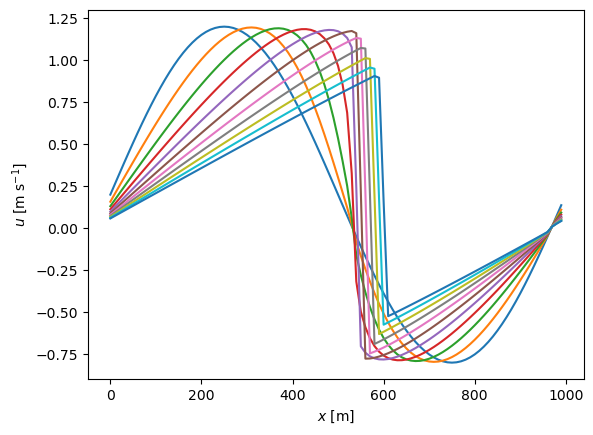

In [6]:
# Check the Burger term
M = DQSWE(100,
          0., # Gravity [m s-2]
          1000., # Max depth [m]
          1000., # Domain width [m]
          0.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          0.e-3, # Drag rate [m-1 s-1]
          0 # Viscosity [m s-2]
          )
M.u = np.sin( 2 * np.pi * M.xu / M.Lx  ) + 0.2
u, v, _, time = M.run(5., 10, 10)
plt.plot(M.xq1, u[:,0,:].T);
plt.xlabel(r"$x$ [m]");
plt.ylabel("$u$ [m s$^{-1}$]");

Grid: dx = 100.0 [m]
cg = 0.0 [m s-1]
Ld = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.0
CFL: dt*nu/dx^2 = 0.1
nsteps = 2
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.0
Running...
...done


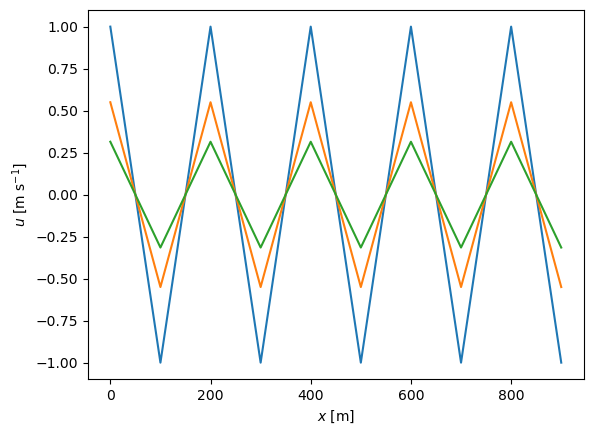

In [7]:
# Check the viscosity term
M = DQSWE(10,
          0., # Gravity [m s-2]
          1000., # Max depth [m]
          1000., # Domain width [m]
          0.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          0.e-3, # Drag rate [m-1 s-1]
          2e2 # Viscosity [m s-2]
          )
M.u = np.cos( np.pi * M.xu / M.dx  )
u, v, _, time = M.run(5., 1, 2)
plt.plot(M.xq1, u[:,0,:].T);
plt.xlabel(r"$x$ [m]");
plt.ylabel("$u$ [m s$^{-1}$]");

Grid: dx = 12500.0 [m]
cg = 50.0 [m s-1]
Ld = None [m]
Scales: Ls=epsilon/D/beta = None [m]
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.0
CFL: dt*cg/dx = 0.8
CFL: dt*nu/dx^2 = 0.0
nsteps = 50
Time: Trun * fo = 0.0
Time: Trun * ( cg / L ) = 0.5
Running...
...done


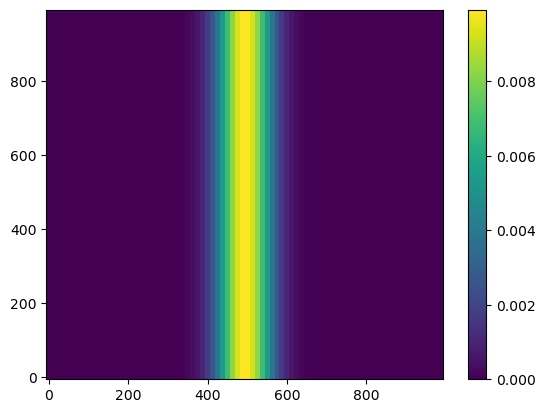

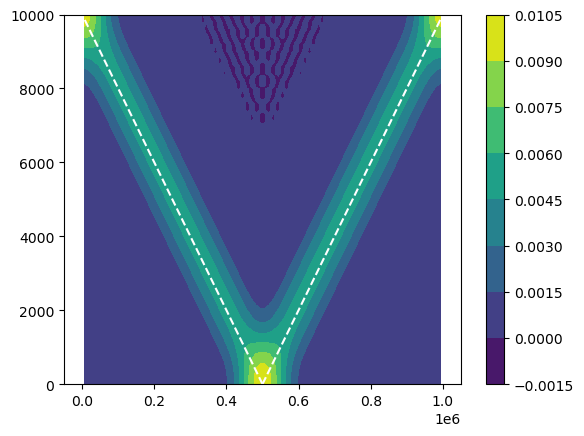

In [8]:
# Check gravity wave propagation
M = DQSWE(80,
          10., # Gravity [m s-2]
          250., # Max depth [m]
          1000.e3, # Domain width [m]
          0.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          0.e-3, # Drag rate [m-1 s-1]
          0e3 # Viscosity [m s-2]
          )
M.perturb_eta(0.01, 50.e3, 500e3) 
plt.pcolormesh( M.xq/1e3, M.yq/1e3, M.eta ); plt.colorbar();

u,v,eta,time = M.run(200.,1,50);
plt.figure();
plt.contourf( M.xh1, time, eta[:,0,:] ); plt.colorbar();
plt.plot( 500e3 + M.cg * time, time, '--w' );
plt.plot( 500e3 - M.cg * time, time, '--w' );

Grid: dx = 25000.0 [m]
cg = 10.0 [m s-1]
Ld = 100000.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Scales: Lx/Ld = 20.0
Res: Ld/dx = 4.0
CFL: dt*epsilon/D = 0.0
CFL: dt*f = 0.005
CFL: dt*cg/dx = 0.02
CFL: dt*nu/dx^2 = 0.0
nsteps = 1250
Time: Trun * fo = 6.25
Time: Trun * ( cg / L ) = 0.3125
Running...
...done


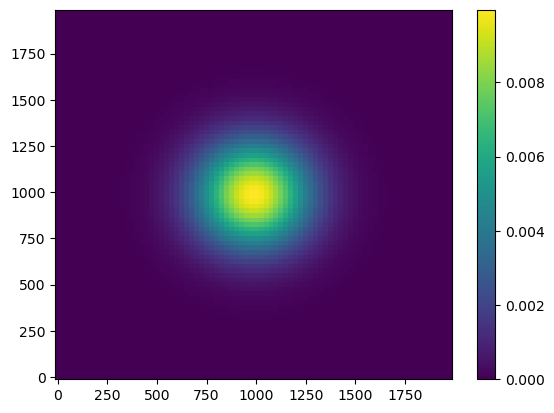

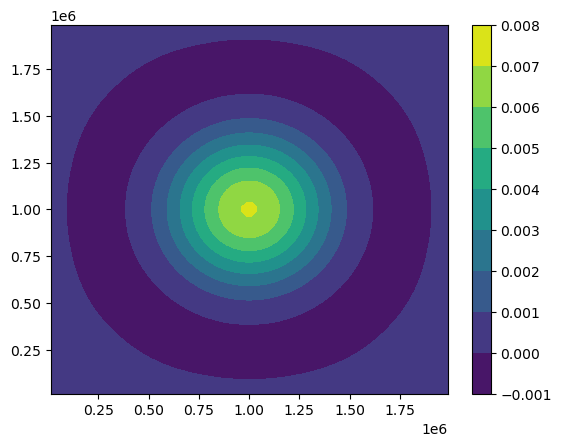

In [9]:
# Geostrophic adjustment problem
M = DQSWE(80,
          10., # Gravity [m s-2]
          10., # Max depth [m]
          2000.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          0.e-3, # Drag rate [m-1 s-1]
          0e3 # Viscosity [m s-2]
          )
M.perturb_eta(0.01, 200.e3, 1000e3, y0=1000e3)
plt.pcolormesh( M.xq/1e3, M.yq/1e3, M.eta ); plt.colorbar();

u,v,eta,time = M.run(50.,1,1250);
plt.figure();
plt.contourf( M.xh1, M.yh1, eta[-1] ); plt.colorbar();

Grid: dx = 7500.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Scales: Lx/Ld = 7.5
Res: Ld/dx = 10.666666666666666


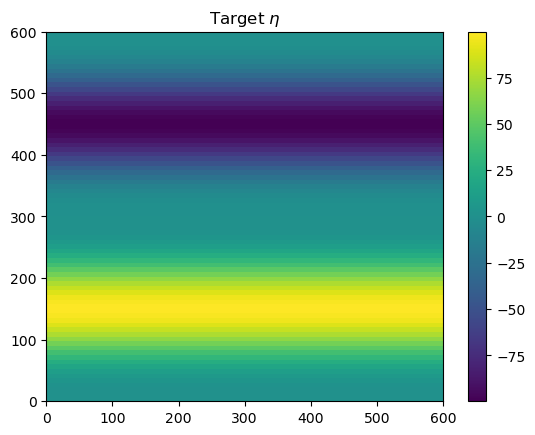

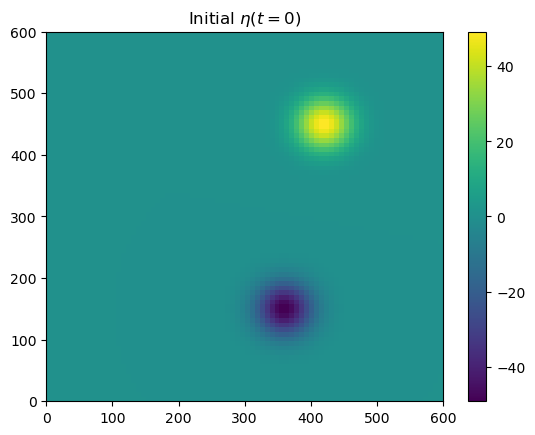

In [10]:
# Barotropic instability in a channel problem
M = DQSWE(80,
          0.08, # Gravity [m s-2]
          800., # Max depth [m]
          600.e3, # Domain width [m]
          1.e-4, # Coriolis [s-1]
          0.e-11, # df/dy [m-1 s-1]
          5.e-4, # Drag rate [m-1 s-1]
          2e1, # Viscosity [m s-2]
          h_relax=1e-5 # Forcing rate on zonal average eta [s-1]
          )
M.set_eta_forcing(100.)
M.perturb_eta(50., 0.05 * M.Lx, 0.7 * M.Lx, 0.75 * M.Ly)
M.perturb_eta(-50., 0.05 * M.Lx, 0.6 * M.Lx, 0.25 * M.Ly)
plt.pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta*0 + M.eta_target ); plt.colorbar(); plt.title(r'Target $\eta$');
plt.figure();
plt.pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta ); plt.colorbar(); plt.title(r'Initial $\eta(t=0)$');

CFL: dt*epsilon/D = 6.25e-05
CFL: dt*f = 0.01
CFL: dt*cg/dx = 0.10666666666666667
CFL: dt*nu/dx^2 = 3.555555555555555e-05
CFL: dt*h_relax = 0.001
nsteps = 200000
Time: Trun * fo = 2000.0
Time: Trun * ( cg / L ) = 266.6666666666667
Running...
...done


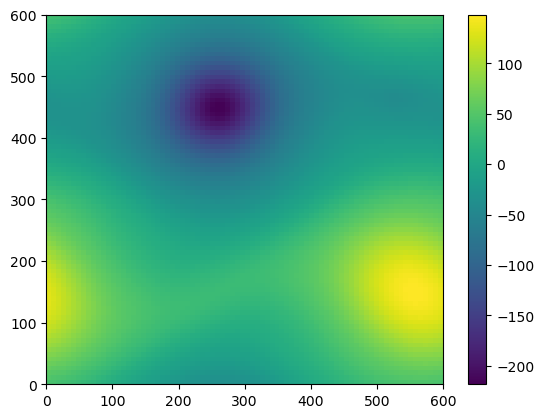

In [11]:
u,v,eta,time = M.run(100., 1000, 200); # dt, steps/segment, segments
plt.pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta ); plt.colorbar();

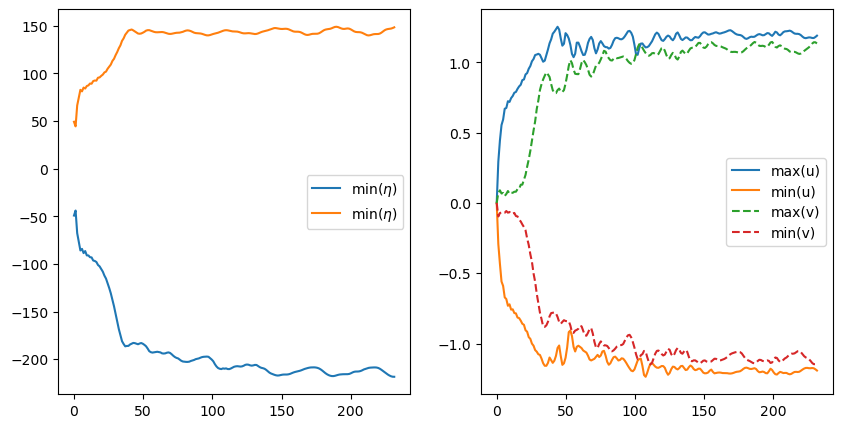

In [12]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot( time/86400, eta.min(axis=(1,2)), label=r'min($\eta$)' )
ax[0].plot( time/86400, eta.max(axis=(1,2)), label=r'min($\eta$)' )
ax[0].legend();
ax[1].plot( time/86400, u.max(axis=(1,2)), label='max(u)' )
ax[1].plot( time/86400, u.min(axis=(1,2)), label='min(u)' )
ax[1].plot( time/86400, v.max(axis=(1,2)), '--', label='max(v)' )
ax[1].plot( time/86400, v.min(axis=(1,2)), '--', label='min(v)' )
ax[1].legend();

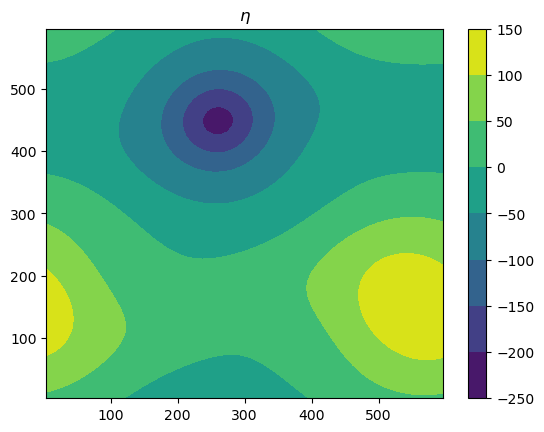

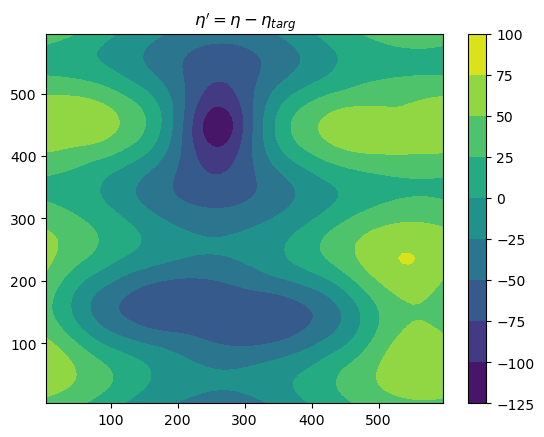

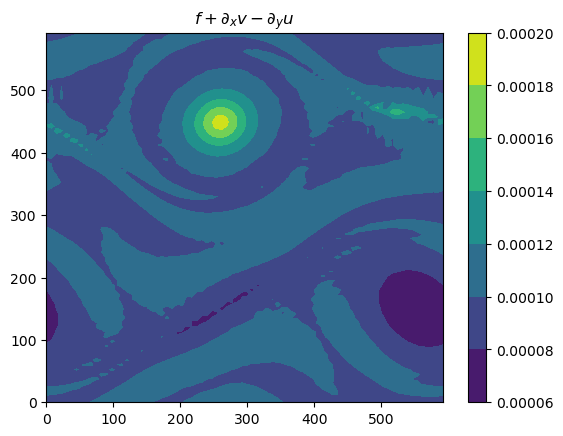

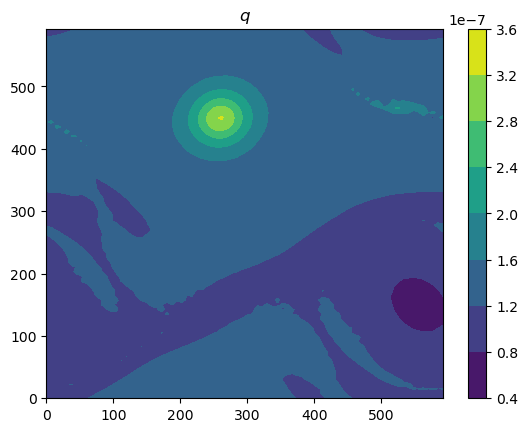

In [13]:
plt.contourf( M.xh1/1e3, M.yh1/1e3, M.eta ); plt.colorbar(); plt.title(r"$\eta$");
plt.figure();
plt.contourf( M.xh1/1e3, M.yh1/1e3, M.eta - M.eta_target ); plt.colorbar(); plt.title(r"$\eta' = \eta - \eta_{targ}$");
plt.figure();
plt.contourf( M.xq1/1e3, M.yq1/1e3, M.abs_omega() ); plt.colorbar(); plt.title(r'$f + \partial_x v - \partial_y u$');
plt.figure();
plt.contourf( M.xq1/1e3, M.yq1/1e3, M.q(eta=eta[-1], u=u[-1], v=v[-1]) ); plt.colorbar(); plt.title(r'$q$');

In [ ]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# fig, ax = plt.subplots()
# # Compute PV for all time levels
# pv = np.array([M.q(eta=eta[n], u=u[n], v=v[n]) for n in range(len(time))])
# # Use consistent color limits across frames
# vmin, vmax = pv.min(), pv.max()
# cf = ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[-1], levels=20, vmin=vmin, vmax=vmax)
# cb = fig.colorbar(cf)
# title = ax.set_title(f'$q$ at t = {time[0]/86400:.2f} days')

# def update(n):
#     ax.clear()
#     ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[n], levels=20, vmin=vmin, vmax=vmax)
#     ax.set_title(f'$q$ at t = {time[n]/86400:.2f} days')

# anim = FuncAnimation(fig, update, frames=len(time), interval=100)
# plt.close(fig)
# HTML(anim.to_jshtml())